## objectives

This notebook implements a ResNet50-based deep learning model for classifying waste image into six categories

The model will use transfer learning with a ResNet50 backbone
pretrained on ImageNet.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Project root directory
PROJECT_ROOT = Path.cwd().parent

import tensorflow as tf

print("TF version: ", tf.__version__)

TF version:  2.18.0


## 1. Experiment Configuration

In [2]:
IMG_SIZE = (256,256)
BATCH_SIZE = 16
NUM_CLASSES = 6
SEED = 42

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("Class Names: ", CLASS_NAMES)
print("Number of Classes: ", NUM_CLASSES)
print("Image Size: ", IMG_SIZE)
print("Batch Size: ", BATCH_SIZE)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Class Names:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of Classes:  6
Image Size:  (256, 256)
Batch Size:  16


In [3]:
TRAIN_CSV = "../data/processed/train.csv"
VAL_CSV = "../data/processed/validation.csv"
TEST_CSV = "../data/processed/test.csv"

print(os.path.exists(TRAIN_CSV))
print(os.path.exists(VAL_CSV))
print(os.path.exists(TEST_CSV))

True
True
True


In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Training: (9692, 3)
Validation: (2114, 3)
Test: (2091, 3)


In [5]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['relative_path', 'class', 'label']

Validation columns:
['relative_path', 'class', 'label']

Test columns:
['relative_path', 'class', 'label']


In [6]:
train_df["class"].value_counts()

class
glass        1751
trash        1750
paper        1605
plastic      1598
cardboard    1548
metal        1440
Name: count, dtype: int64

In [7]:
sorted(train_df["class"].unique())
print("Number of classes:", train_df["label"].nunique())

Number of classes: 6


In [9]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64
relative_path    0
class            0
label            0
dtype: int64


In [10]:
print("Duplicate training rows:", train_df.duplicated().sum())
print("Duplicate validation rows:", val_df.duplicated().sum())
print("Duplicate test rows:", test_df.duplicated().sum())

Duplicate training rows: 0
Duplicate validation rows: 0
Duplicate test rows: 0


In [8]:
train_df.head()

,relative_path,class,label
0,cardboard/cardboard_00001.jpg,cardboard,0
1,cardboard/cardboard_00007.jpg,cardboard,0
2,cardboard/cardboard_00012.jpg,cardboard,0
3,cardboard/cardboard_00013.jpg,cardboard,0
4,cardboard/cardboard_00016.jpg,cardboard,0


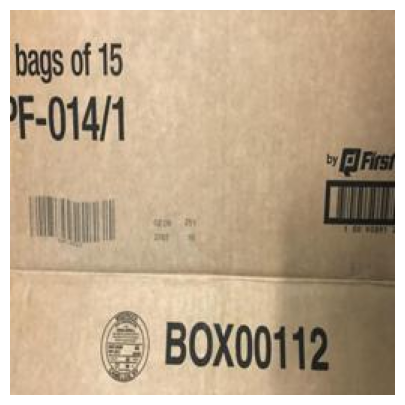

Image size: (256, 256)
Image mode: RGB


In [9]:
image = Image.open("../data/raw/Garbage_Dataset_Classification/images/cardboard/cardboard_00001.jpg")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

print("Image size:", image.size)
print("Image mode:", image.mode)

## 6. ResNet50 Data Preprocessing

In [10]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from pathlib import Path

IMAGE_ROOT = Path("../data/raw/Garbage_Dataset_Classification/images/")

def load_and_preprocess_image(relative_path):
    image_path = IMAGE_ROOT / relative_path

    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)
    image = np.array(image, dtype=np.float32)
    image = preprocess_input(image)
    return image

sample_img = load_and_preprocess_image(train_df.iloc[0]["relative_path"])
print("Shape:", sample_img.shape)
print("Data type:", sample_img.dtype)
print("Min value:", sample_img.min())
print("Max value:", sample_img.max())

Shape: (256, 256, 3)
Data type: float32
Min value: -115.68
Max value: 131.32


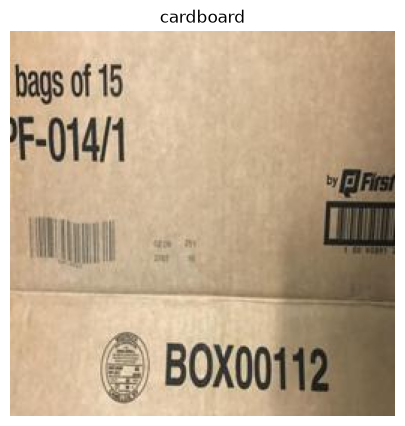

In [11]:
image_path = IMAGE_ROOT / train_df.iloc[0]["relative_path"]

original_image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.axis("off")
plt.title(train_df.iloc[0]["class"])
plt.show()

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")

In [13]:
def create_dataset(dataframe, training=False):
    paths = dataframe["relative_path"].values
    labels = dataframe["label"].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )
    
    return dataset

In [14]:
def process_image(path, label, training=False):
    
    image_path = tf.strings.join(
        [str(IMAGE_ROOT), "/", path]
    )
    
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(
        image,
        tf.float32
    )
    
    if training:
        image = data_augmentation(image, training=True)
    
    image = preprocess_input(image)
    
    return image, label

In [15]:
def build_dataset(dataframe, training=False):
    dataset = create_dataset(dataframe, training=training)

    dataset = dataset.map(
        lambda path, label: process_image(path, label, training=training),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_dataset = build_dataset(train_df, training=True)
val_dataset = build_dataset(val_df, training=False)
test_dataset = build_dataset(test_df, training=False)

In [16]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)

Image batch shape: (16, 256, 256, 3)
Label batch shape: (16,)
Image dtype: <dtype: 'float32'>


In [17]:
print(labels.numpy())

[5 1 4 2 3 0 5 3 2 4 2 3 3 5 3 0]


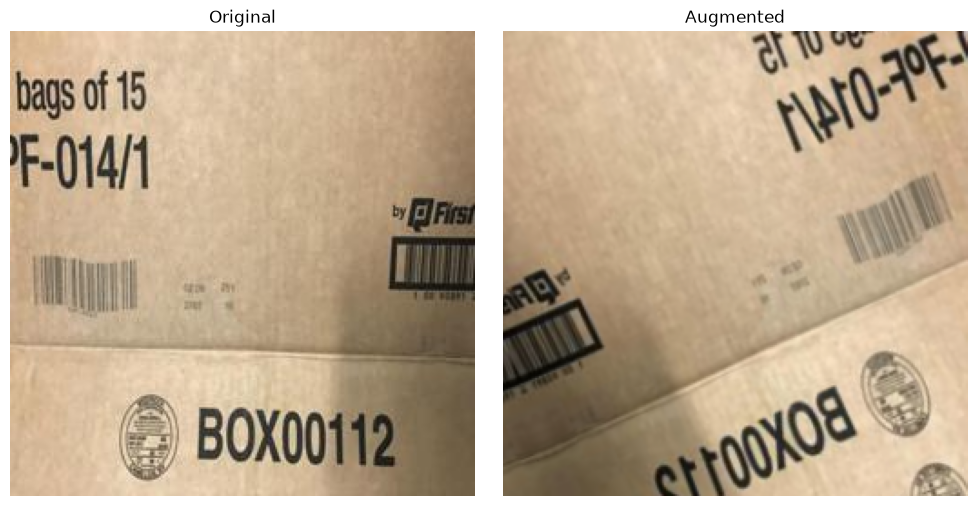

In [18]:
row = train_df.iloc[0]

image_path = IMAGE_ROOT / row["relative_path"]

image = Image.open(image_path).convert("RGB")

image = np.array(image)

image_tensor = tf.convert_to_tensor(
    image,
    dtype=tf.float32
)

augmented = data_augmentation(
    image_tensor,
    training=True
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.astype(np.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(
    tf.clip_by_value(augmented, 0, 255),
    tf.uint8
))
plt.title("Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

# 3. ResNet50 Model Architecture

In [19]:
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras import layers
from tensorflow.keras import models

# Load the ResNet50 model without the top layer and with ImageNet weights
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# freez restnet weigjhts to avoid retraining them
base_model.trainable = False

# Add custom classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

# compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=["accuracy"]
)

# Check the model's trainable parameters
trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.non_trainable_weights
)

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Trainable parameters: 263046
Non-trainable parameters: 23587712


# 4. Train ResNet50

In [ ]:
EPOCHS = 15
LEARNING_RATE = 0.001

# early stop if the loss dosne't improved
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

#save the best model based on validation accuracy
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/resnet50_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# check weather directory exsist
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model directory:", MODEL_DIR)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_DIR / "resnet50_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# reduce the learning rate if the validation loss doesn't improve
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# check weather model is compiled or not
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# verify the dataset before training 
images, labels = next(iter(train_dataset))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Label examples:", labels[:10].numpy())

# verify validation dataset
val_images, val_labels = next(iter(val_dataset))

print("Validation images:", val_images.shape)
print("Validation labels:", val_labels.shape)

# train
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ]
)

Model directory: d:\UNI\SE4050-Automatic-Waste-Classification\models
Images: (16, 256, 256, 3)
Labels: (16,)
Label examples: [0 3 4 5 3 1 0 1 0 0]
Validation images: (16, 256, 256, 3)
Validation labels: (16,)
Epoch 1/15


c:\Users\CVR\miniconda3\envs\waste-dl\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 10/606 ━━━━━━━━━━━━━━━━━━━━ 5:23 543ms/step - accuracy: 0.3000 - loss: 2.0989

KeyboardInterrupt: 

# 5.Fine Tuning RestNet50

In [ ]:
best_model = tf.keras.models.load_model(
    MODEL_DIR / "resnet50_best.keras"
)

print("Best model loaded successfully.")

base_model = best_model.layers[0]


fine_tune_from = int(len(base_model.layers) * 0.80)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# check trainable parameters
trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in best_model.non_trainable_weights
)

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

FINE_TUNE_LR = 1e-5

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_DIR / "resnet50_finetuned_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# trained the fibe tuned model
FINE_TUNE_EPOCHS = 10

fine_tune_history = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_checkpoint,
        fine_tune_reduce_lr
    ]
)

Best model loaded successfully.
Trainable parameters: 15216518
Non-trainable parameters: 8634240
Epoch 1/10
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9457 - loss: 0.1578
Epoch 1: val_loss improved from None to 0.20139, saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_finetuned_best.keras

Epoch 1: finished saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_finetuned_best.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 892s 1s/step - accuracy: 0.9457 - loss: 0.1578 - val_accuracy: 0.9319 - val_loss: 0.2014 - learning_rate: 1.0000e-05
Epoch 2/10
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9535 - loss: 0.1345
Epoch 2: val_loss improved from 0.20139 to 0.19818, saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_finetuned_best.keras

Epoch 2: finished saving model to d:\UNI\SE4050-Automatic-Waste-Classification\models\resnet50_finetuned_best.keras
606/606 ━━━━━━━━━━━━━━━━━━━━ 896s 1s/step - accuracy: 0.